In [20]:
#Importamos las librerias
import pandas as pd
import requests
from io import StringIO
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.0f}'.format

In [10]:
#Consumimos el dataset de github
url = "https://raw.githubusercontent.com/JuanJoseGomez1307/ecommerce-data-analytics-project/main/DATA/ecommerce_sales_dataset.csv"

response = requests.get(url)

#Creamos el DataFrame
df = pd.read_csv(StringIO(response.text))

df.head()

,SALE_ID,DATE_ID,FULL_DATE,MONTH,MONTH_NAME,YEAR,CUSTOMER_ID,GENDER,AGE,PRODUCT_ID,PRODUCT_NAME,BRAND,CATEGORY_NAME,QUANTITY,UNIT_PRICE,TOTAL_AMOUNT
0,255,20230101,01/01/23,1,January,2023,10,Female,47,5,Tablet,NaN,Electrónica,2,500,1000
1,1755,20230920,20/09/23,9,September,2023,1373,Female,51,13,Jeans,NaN,Hogar Inteligente,2,54481,108962
2,1756,20230824,24/08/23,8,August,2023,927,Female,47,25,Chocolate,NaN,Oficina,5,175111,875555
3,1757,20230101,01/01/23,1,January,2023,610,Male,35,15,Sneakers,NaN,Hogar Inteligente,3,169671,509013
4,1758,20241102,02/11/24,11,November,2024,64,Female,62,13,Jeans,NaN,Hogar Inteligente,4,48283,193132


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SALE_ID        50001 non-null  int64  
 1   DATE_ID        50001 non-null  int64  
 2   FULL_DATE      50001 non-null  object 
 3   MONTH          50001 non-null  int64  
 4   MONTH_NAME     50001 non-null  object 
 5   YEAR           50001 non-null  int64  
 6   CUSTOMER_ID    50001 non-null  int64  
 7   GENDER         50001 non-null  object 
 8   AGE            50001 non-null  int64  
 9   PRODUCT_ID     50001 non-null  int64  
 10  PRODUCT_NAME   50001 non-null  object 
 11  BRAND          0 non-null      float64
 12  CATEGORY_NAME  50001 non-null  object 
 13  QUANTITY       50001 non-null  int64  
 14  UNIT_PRICE     50001 non-null  int64  
 15  TOTAL_AMOUNT   50001 non-null  int64  
dtypes: float64(1), int64(10), object(5)
memory usage: 6.1+ MB


In [ ]:
df.describe()

,SALE_ID,DATE_ID,MONTH,YEAR,CUSTOMER_ID,AGE,PRODUCT_ID,BRAND,QUANTITY,UNIT_PRICE,TOTAL_AMOUNT
count,50001.000000,5.000100e+04,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000,0.0,50001.000000,50001.000000,50001.000000
mean,26753.970021,2.023069e+07,6.508290,2023.001960,749.385572,41.218736,13.461011,NaN,2.995980,92366.152077,228548.457291
std,14434.243224,8.172119e+03,3.454408,0.816698,432.753885,13.681480,7.501565,NaN,1.413295,60785.045131,221177.000544
min,255.000000,2.022010e+07,1.000000,2022.000000,1.000000,18.000000,1.000000,NaN,1.000000,203.000000,212.000000
25%,14254.000000,2.022100e+07,4.000000,2022.000000,374.000000,30.000000,7.000000,NaN,2.000000,34931.000000,53382.000000
50%,26754.000000,2.023070e+07,7.000000,2023.000000,749.000000,41.000000,13.000000,NaN,3.000000,91025.000000,151318.000000
75%,39254.000000,2.024033e+07,10.000000,2024.000000,1123.000000,53.000000,20.000000,NaN,4.000000,145239.000000,352678.000000
max,51754.000000,2.024123e+07,12.000000,2024.000000,1500.000000,65.000000,26.000000,NaN,5.000000,199998.000000,999915.000000


In [ ]:
#Columnas del DataFrame
df.columns

Index(['SALE_ID', 'DATE_ID', 'FULL_DATE', 'MONTH', 'MONTH_NAME', 'YEAR',
       'CUSTOMER_ID', 'GENDER', 'AGE', 'PRODUCT_ID', 'PRODUCT_NAME', 'BRAND',
       'CATEGORY_NAME', 'QUANTITY', 'UNIT_PRICE', 'TOTAL_AMOUNT'],
      dtype='object')

In [11]:
#Total de ventas
df['TOTAL_AMOUNT'].sum()

np.int64(11427651413)

In [ ]:
#Cantidad de ventas
df.shape[0]

50001

In [ ]:
#Clientes unicos
df['CUSTOMER_ID'].nunique()

1500

In [ ]:
#Productos unicos
df['PRODUCT_ID'].nunique()

26

In [5]:
#Productos más vendidos
top_products = df.groupby("PRODUCT_NAME")["QUANTITY"].sum().sort_values(ascending=False).head(10)

top_products

,QUANTITY
PRODUCT_NAME,
Drawer Cabinet,5976
Basketball,5953
Tablet,5950
Headphones,5870
Bookshelf,5867
Sneakers,5843
Hat,5839
Monitor,5837
Coffee,5818


In [19]:
#Agrupamos las ventas por Categoria
sales_category = df.groupby("CATEGORY_NAME")["TOTAL_AMOUNT"].sum().sort_values(ascending=False)

sales_category.apply(lambda x: f"{x:,.0f}")

,TOTAL_AMOUNT
CATEGORY_NAME,
Electrónica,"2,671,036,774"
Hogar Inteligente,"2,197,502,049"
Accesorios Tecnológicos,"2,197,444,601"
Oficina,"2,186,831,577"
Gaming,"2,174,836,412"


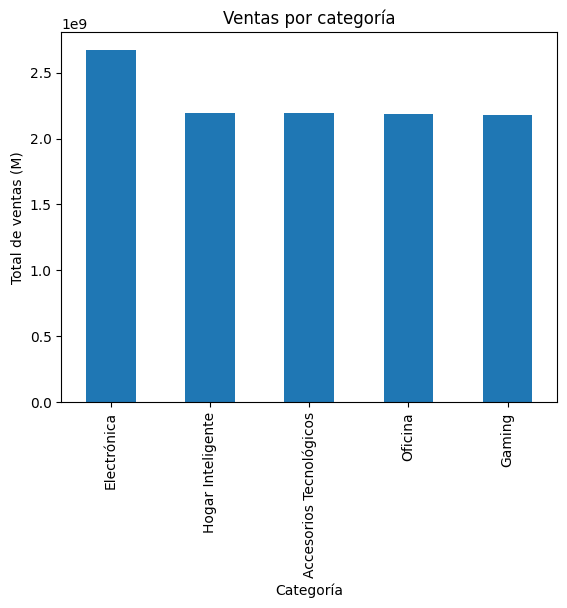

In [22]:
#Graficamos sales_category
sales_category.plot(kind="bar")

plt.title("Ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Total de ventas (M)")

plt.show()

In [29]:
#Convertimos la columna FULL_DATE en tipo DATETIME
df["FULL_DATE"] = pd.to_datetime(df["FULL_DATE"])

/tmp/ipykernel_231/69283561.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FULL_DATE"] = pd.to_datetime(df["FULL_DATE"])


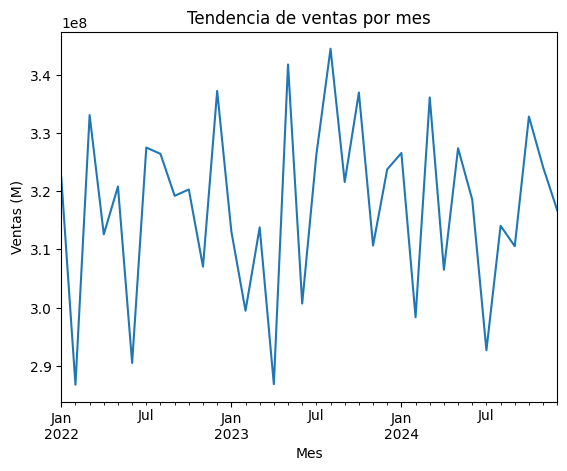

In [32]:
#Agrupamos y graficamos la tendencia de ventas en el tiempo
sales_month = df.groupby(df["FULL_DATE"].dt.to_period("M"))["TOTAL_AMOUNT"].sum()

sales_month.plot()

plt.title("Tendencia de ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas (M)")

plt.show()

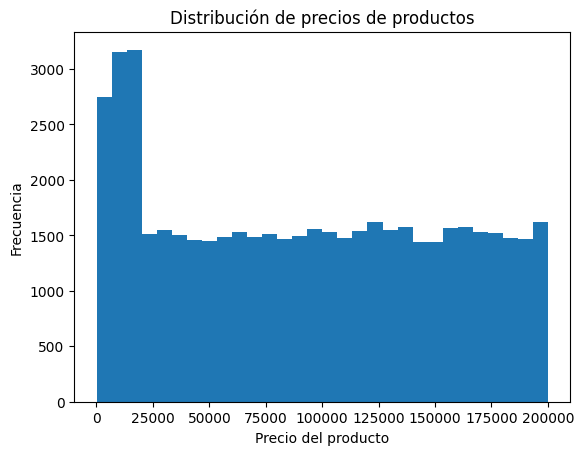

In [33]:
#Distribución de precios (Histograma)
plt.figure()

plt.hist(df["UNIT_PRICE"], bins=30)

plt.title("Distribución de precios de productos")
plt.xlabel("Precio del producto")
plt.ylabel("Frecuencia")

plt.show()

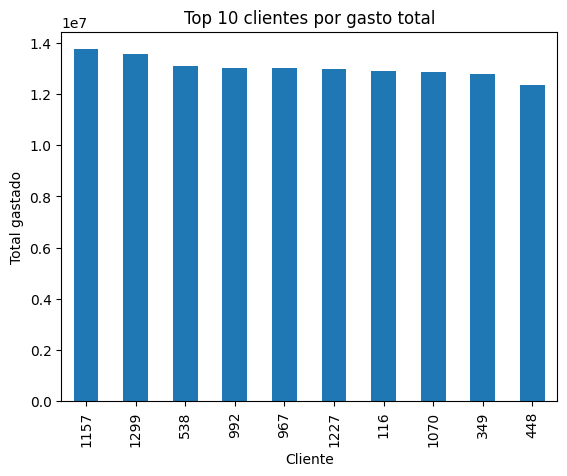

In [34]:
#Top 10 Clientes por gasto total
top_customers = df.groupby("CUSTOMER_ID")["TOTAL_AMOUNT"].sum().sort_values(ascending=False).head(10)

plt.figure()

top_customers.plot(kind="bar")

plt.title("Top 10 clientes por gasto total")
plt.xlabel("Cliente")
plt.ylabel("Total gastado")

plt.show()

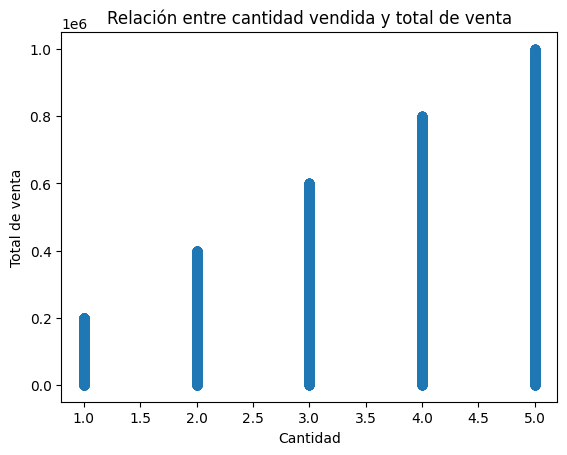

In [35]:
#Cantidad vendida vs valor de venta
plt.figure()

plt.scatter(df["QUANTITY"], df["TOTAL_AMOUNT"])

plt.title("Relación entre cantidad vendida y total de venta")
plt.xlabel("Cantidad")
plt.ylabel("Total de venta")

plt.show()

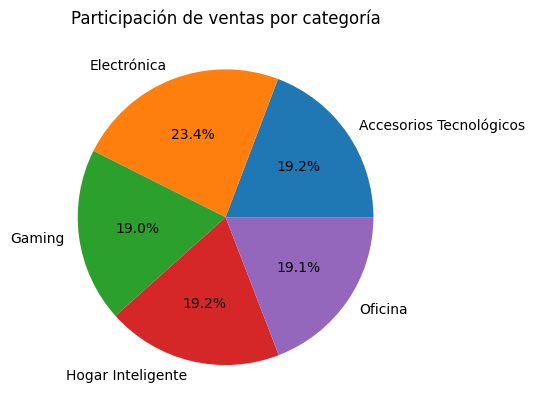

In [36]:
#Participación de Ventas por categoria
sales_category = df.groupby("CATEGORY_NAME")["TOTAL_AMOUNT"].sum()

plt.figure()

plt.pie(
    sales_category,
    labels=sales_category.index,
    autopct='%1.1f%%'
)

plt.title("Participación de ventas por categoría")

plt.show()

<Figure size 640x480 with 0 Axes>

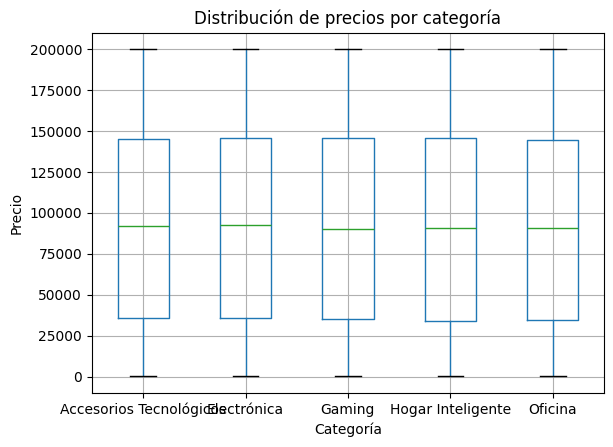

In [37]:
#Distribución de Precios por Categoria
plt.figure()

df.boxplot(column="UNIT_PRICE", by="CATEGORY_NAME")

plt.title("Distribución de precios por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Precio")

plt.show()

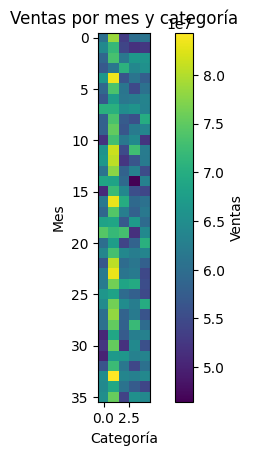

In [42]:
#Heatmap de Ventas por Mes y Categoria
df["FULL_DATE"] = pd.to_datetime(df["DATE_ID"], format="%Y%m%d")

df["MONTH"] = df["FULL_DATE"].dt.to_period("M")

#Generamos la tabla
sales_heatmap = df.pivot_table(
    values="TOTAL_AMOUNT",
    index="MONTH",
    columns="CATEGORY_NAME",
    aggfunc="sum"
)

#Generamos el Grafico
plt.figure()

plt.imshow(sales_heatmap)

plt.title("Ventas por mes y categoría")
plt.xlabel("Categoría")
plt.ylabel("Mes")

plt.colorbar(label="Ventas")

plt.show()